In [1]:
import pandas as pd 
import numpy as np 
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split # sklearn.model_selection use for splitting data between training and testing
from sklearn.preprocessing import StandardScaler # sklearn.preprocessing for scaling standards 
import os 

In [2]:
hdf = fetch_california_housing(as_frame=True)
hdf.DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 20640\n\n:Number of Attributes: 8 numeric, predictive attributes and the target\n\n:Attribute Information:\n    - MedInc        median income in block group\n    - HouseAge      median house age in block group\n    - AveRooms      average number of rooms per household\n    - AveBedrms     average number of bedrooms per household\n    - Population    block group population\n    - AveOccup      average number of household members\n    - Latitude      block group latitude\n    - Longitude     block group longitude\n\n:Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000).\n\nThis dataset was derived from the 1990 U.S

In [3]:
df = pd.DataFrame(hdf.data, columns = hdf.feature_names)

In [4]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [ ]:
# I have not made a read me before so I am using ChatGPT to help me write one! 

# This portion is updated near the bottom of the notebook to include everything needed for the assignment as is therefore overwritten. 

# I am just leaving it here for grading purposes.

with open("README.md","w") as f:

    f.write("# California Housing Dataset Exploration \n\n")
    f.write("This project performs an initial exploration of the"
            "California Housing dataset provided by Scikit-learn.\n\n")

    # Data description
    f.write('## Dataset Description \n\n')
    f.write("``` text \n")
    f.write(hdf.DESCR)
    f.write("\n```\n")

    f.write('## Frist 5 Rows\n\n')
    f.write("```text\n")
    f.write(df.head().to_string())
    f.write("\n```\n")

    f.write("## Summary Statistics\n\n")
    f.write("```text\n")
    f.write(df.describe().to_string())
    f.write("\n```\n")  

print("READ.md successfully created!")




READ.md successfully created!


### We need inputs, X , and outputs, Y, for training a machine learning model. The dataset can be split between what we know and what we want to know. 

In [8]:
# seperate features known as X and targets known as Y 

df["MedHouseVal"] = hdf.target

X = df.drop(columns=["MedHouseVal"])
Y = df["MedHouseVal"]

In [9]:
# Train-test split
# split between 80% training and 20% testing 
# random_state = 0 for reproducibility 

x_train, x_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size = 0.20,
    random_state = 0
)

print("Training feature shape", x_train.shape)
print("Testing feature shape", x_test.shape)

print("Training target shape", y_train.shape)
print("Testing target shape", y_test.shape)

Training feature shape (16512, 8)
Testing feature shape (4128, 8)
Training target shape (16512,)
Testing target shape (4128,)


In [10]:
# feature scaling 

scaler = StandardScaler()

# fit only on training data and transform them 
# fit_transform will calculate the mean and standarad deviation of every feature using only the training set
# fit_transform will also use the scaled values to standardize the training data

x_train_scaled = scaler.fit_transform(x_train)

# use same scaler to transform the test data
# don't use fit_transform here, data leakage will occur, z = x - mu / sigma where mu & sigma are calculated from training data 
x_test_scaled = scaler.transform(x_test)

print(x_train_scaled[:5])

[[ 0.19001247 -1.79507596  0.90771428  0.1492426  -1.04760128  0.07408222
  -0.8400624   1.00389865]
 [ 0.26931072  1.85553889 -0.04200187  0.00918616  0.05210918  0.04527606
   0.98536392 -1.43477229]
 [ 0.02989505 -0.20785212 -0.30282448 -0.10209862 -0.35295521 -0.03933216
  -0.8400624   0.77948108]
 [-1.26447048  0.74448219 -0.81206385 -0.1766356  -0.59179448  0.09399018
  -0.75581196  0.64981759]
 [-0.36701574  1.85553889 -0.52026922 -0.10780402 -0.25409501 -0.16457198
  -0.72304789  0.59994702]]


In [11]:
# Convert scaled arrays back into DataFrames
x_train_scaled = pd.DataFrame(
    x_train_scaled,
    columns=X.columns,
    index=x_train.index
)

x_test_scaled = pd.DataFrame(
    x_test_scaled,
    columns=X.columns,
    index=x_test.index
)

print("\nScaled training data:")
print(x_train_scaled.head())

print("\nTraining feature means after scaling:")
print(x_train_scaled.mean())

print("\nTraining feature standard deviations after scaling:")
print(x_train_scaled.std())


Scaled training data:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
12069  0.190012 -1.795076  0.907714   0.149243   -1.047601  0.074082   
15925  0.269311  1.855539 -0.042002   0.009186    0.052109  0.045276   
11162  0.029895 -0.207852 -0.302824  -0.102099   -0.352955 -0.039332   
4904  -1.264470  0.744482 -0.812064  -0.176636   -0.591794  0.093990   
4683  -0.367016  1.855539 -0.520269  -0.107804   -0.254095 -0.164572   

       Latitude  Longitude  
12069 -0.840062   1.003899  
15925  0.985364  -1.434772  
11162 -0.840062   0.779481  
4904  -0.755812   0.649818  
4683  -0.723048   0.599947  

Training feature means after scaling:
MedInc       -9.778999e-17
HouseAge     -7.939386e-17
AveRooms     -3.262356e-17
AveBedrms    -1.053206e-16
Population   -3.550132e-18
AveOccup     -1.140345e-17
Latitude      6.915226e-16
Longitude    -1.134805e-14
dtype: float64

Training feature standard deviations after scaling:
MedInc        1.00003
HouseAge      1.00003
Ave

In [12]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(x_train_scaled,y_train)

print("Linear Sklearn model trained!")

Linear Sklearn model trained!


In [13]:
import torch 
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(0)

x_train_tensor = torch.tensor(
    np.asarray(x_train_scaled),
    dtype = torch.float32
)

x_test_tensor = torch.tensor(
    np.asarray(x_test_scaled),
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    np.asarray(y_train).reshape(-1,1),
    dtype = torch.float32
)
y_test_tensor = torch.tensor(
    np.asarray(y_test).reshape(-1,1),
    dtype = torch.float32
)

print("X_train:", x_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_test:", x_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_train: torch.Size([16512, 8])
y_train: torch.Size([16512, 1])
X_test: torch.Size([4128, 8])
y_test: torch.Size([4128, 1])


In [14]:
class MLP(nn.Module):

    def __init__(self,input_size, hidden_size = 32):
        super(MLP,self).__init__()

        self.hidden = nn.Linear(input_size, hidden_size)

        self.relu = nn.ReLU()

        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):

        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)

        return x

In [15]:
input_size = x_train_tensor.shape[1]

model = MLP(
    input_size = input_size,
    hidden_size = 32
)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr = 0.01
)

print (model)

MLP(
  (hidden): Linear(in_features=8, out_features=32, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=32, out_features=1, bias=True)
)


In [16]:
num_epochs = 100

train_losses = []

epoch_list = []

for epoch in range(1, num_epochs + 1):

    model.train()

    # computes y = f(X;theta) where theta represents all the nn weights and biases
    predictions = model(x_train_tensor)

    # calculates the mean squared error (MSEloss) MSE = 1/N SUM(y_i - y_mean_i)^2
    loss = criterion(predictions, y_train_tensor)

    # clears gradients from previous iteration
    optimizer.zero_grad()

    # performs backpropagation via gradient decent on every weight
    loss.backward()

    # updates the wights to reduce loss
    optimizer.step()

    # attaching losses found to view later
    train_losses.append(loss.item())
    epoch_list.append(epoch)

    # comparing epochs and losses, losses should move towards 0 after several epochs
    if epoch % 10 == 0:
        print(
            f"Epoch [{epoch}/{num_epochs}],"
            f"Loss: {loss.item():.4f}"
        )


Epoch [10/100],Loss: 2.8868
Epoch [20/100],Loss: 1.1202
Epoch [30/100],Loss: 0.8989
Epoch [40/100],Loss: 0.7105
Epoch [50/100],Loss: 0.6214
Epoch [60/100],Loss: 0.5531
Epoch [70/100],Loss: 0.5015
Epoch [80/100],Loss: 0.4661
Epoch [90/100],Loss: 0.4427
Epoch [100/100],Loss: 0.4281


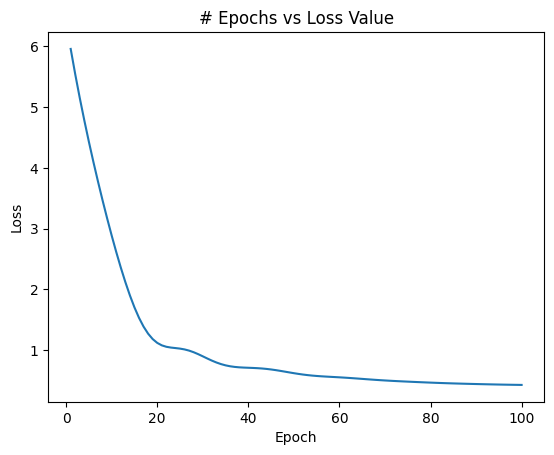

In [33]:
import matplotlib.pyplot as plt

plt.plot(epoch_list,train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("# Epochs vs Loss Value")

plt.savefig(
    "loss_curve.png",
    dpi = 300,
    bbox_inches = 'tight'
)

In [30]:
from sklearn.metrics import mean_squared_error, r2_score

linear_predictions = linear_model.predict(x_test_scaled)

model.eval()

with torch.no_grad():
    nn_predictions_tensor = model(x_test_tensor)

nn_predictions = nn_predictions_tensor.numpy().flatten()

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_rms = np.sqrt(linear_mse)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

nn_mse = mean_squared_error(
    y_test,
    nn_predictions
)

nn_rmse = np.sqrt(nn_mse)

nn_r2 = r2_score(
    y_test,
    nn_predictions
)

print("LINEAR REGRESSION")
print("-------------------------------")
print(f"MSE: {linear_mse:.4f}")
print(f"RMSE: {linear_rms:.4f}")
print(f"R^2: {linear_r2:.4f}")

print()

print("NEURAL NETWORK")
print("---------------------------------")
print(f"MSE: {nn_mse:.4f}")
print(f"RMSE: {nn_rmse:.4f}")
print(f"R^2: {nn_r2:.4f}")

LINEAR REGRESSION
-------------------------------
MSE: 0.5290
RMSE: 0.7273
R^2: 0.5943

NEURAL NETWORK
---------------------------------
MSE: 0.4269
RMSE: 0.6534
R^2: 0.6726


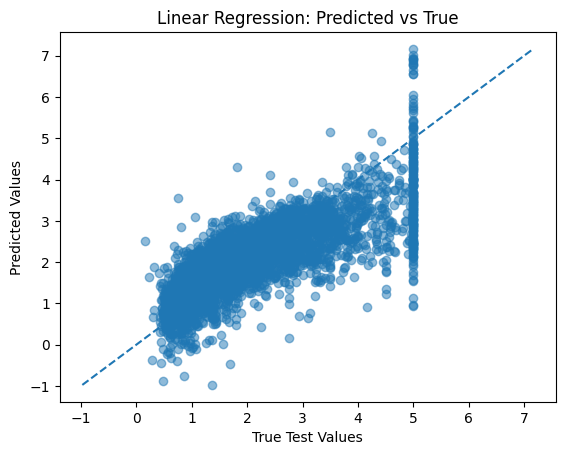

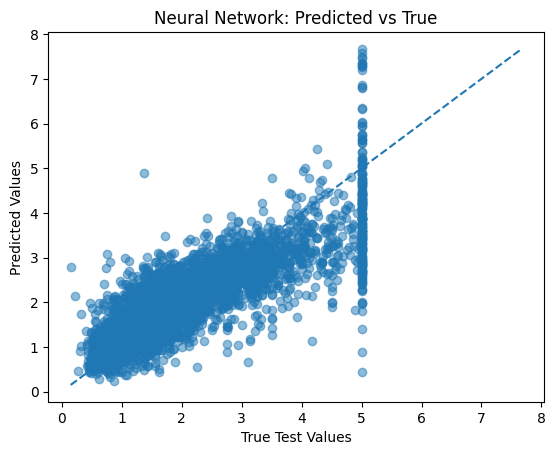

In [45]:
plt.scatter(y_test, linear_predictions, alpha=0.5)

min_val = min(y_test.min(), linear_predictions.min())
max_val = max(y_test.max(), linear_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    '--'
)

plt.xlabel("True Test Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Predicted vs True")
plt.show()

plt.scatter(y_test, nn_predictions, alpha=0.5)

min_val = min(y_test.min(), nn_predictions.min())
max_val = max(y_test.max(), nn_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    '--'
)

plt.xlabel("True Test Values")
plt.ylabel("Predicted Values")
plt.title("Neural Network: Predicted vs True")
plt.show()

In [37]:
# ============================================================
# GENERATE README.md
# ============================================================

# Determine which model performed better
if nn_mse < linear_mse:
    better_model = "Neural Network"
    comparison_text = (
        "The Neural Network performed better than the Linear Regression "
        "model on the test data. It achieved a lower MSE and RMSE, meaning "
        "that its predictions were closer to the true median house values. "
        "It also achieved a higher R² score, indicating that it explained "
        "more of the variation in the target variable."
    )
else:
    better_model = "Linear Regression"
    comparison_text = (
        "The Linear Regression model performed better than the Neural "
        "Network on the test data. It achieved a lower MSE and RMSE, meaning "
        "that its predictions were closer to the true median house values. "
        "It also achieved a higher R² score, indicating that it explained "
        "more of the variation in the target variable."
    )


# Calculate how much the neural network training loss decreased
initial_loss = train_losses[0]
final_loss = train_losses[-1]

loss_reduction = (
    (initial_loss - final_loss) / initial_loss
) * 100


# Description of neural-network training
loss_analysis = (
    f"The neural network training loss decreased from "
    f"{initial_loss:.4f} at the beginning of training to "
    f"{final_loss:.4f} after {num_epochs} epochs. "
    f"This represents a reduction of approximately "
    f"{loss_reduction:.2f}% in the training loss. "
    "The decrease in loss indicates that the neural network learned "
    "patterns relating the input housing features to median house values. "
    "The largest improvements generally occur during the earlier epochs, "
    "while the rate of improvement becomes smaller later in training. "
    "This behavior indicates that the model is moving toward convergence."
)


# ============================================================
# WRITE README
# ============================================================

with open("README.md", "w", encoding="utf-8") as f:

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    f.write("# Assignment 2: California Housing Regression\n\n")

    f.write(
        "This project explores the California Housing dataset and "
        "compares a baseline Linear Regression model with a shallow "
        "Neural Network implemented using PyTorch.\n\n"
    )

    f.write("---\n\n")


    # --------------------------------------------------------
    # HOW TO RUN
    # --------------------------------------------------------

    f.write("# Running the Code\n\n")

    f.write(
        "Create and activate the Conda environment using the "
        "required library versions:\n\n"
    )

    f.write("```bash\n")

    f.write(
        "conda create -n env_csci4425 python=3.12.2\n"
    )

    f.write(
        "conda activate env_csci4425\n"
    )

    f.write(
        "conda install numpy=2.4.1\n"
    )

    f.write(
        "conda install matplotlib=3.10.8\n"
    )

    f.write(
        "conda install pandas=2.3.3\n"
    )

    f.write(
        "conda install scikit-learn=1.8.0\n"
    )

    f.write(
        "conda install -c conda-forge scikit-datasets=0.2.5\n"
    )

    f.write(
        "conda install pytorch=2.5.1 "
        "torchvision=0.20.1 "
        "torchaudio=2.5.1\n"
    )

    f.write("```\n\n")

    f.write("Run the program using:\n\n")

    f.write("```bash\n")
    f.write("python hw2.py\n")
    f.write("```\n\n")

    f.write("---\n\n")


    # ========================================================
    # PART 1
    # ========================================================

    f.write("# Part 1: Dataset Exploration\n\n")

    f.write(
        "The California Housing dataset was loaded using "
        "`fetch_california_housing()` from Scikit-learn.\n\n"
    )


    # Dataset description
    f.write("## Dataset Description\n\n")

    f.write("```text\n")
    f.write(hdf.DESCR)
    f.write("\n```\n\n")


    # First five rows
    f.write("## First Five Rows\n\n")

    f.write("```text\n")
    f.write(df.head().to_string())
    f.write("\n```\n\n")


    # Summary statistics
    f.write("## Summary Statistics\n\n")

    f.write("```text\n")
    f.write(df.describe().to_string())
    f.write("\n```\n\n")

    f.write("---\n\n")


    # ========================================================
    # PART 2
    # ========================================================

    f.write("# Part 2: Data Preprocessing\n\n")

    f.write(
        "The dataset was separated into input features (`X`) and "
        "the target variable (`MedHouseVal`). The data was then split "
        "into an 80% training set and a 20% testing set using "
        "`random_state=0` for reproducibility.\n\n"
    )

    f.write(
        "The input features were standardized using Scikit-learn's "
        "`StandardScaler`. The scaler was fitted only on the training "
        "data (`X_train`) to prevent information from the test set from "
        "leaking into the training process. The fitted scaler was then "
        "used to transform both `X_train` and `X_test`.\n\n"
    )

    f.write(
        f"- Training samples: **{len(x_train)}**\n"
    )

    f.write(
        f"- Testing samples: **{len(x_test)}**\n"
    )

    f.write(
        f"- Number of input features: **{x_train.shape[1]}**\n\n"
    )

    f.write("---\n\n")


    # ========================================================
    # PART 3
    # ========================================================

    f.write("# Part 3: Model Building and Training\n\n")


    # Linear Regression
    f.write("## Model 1: Linear Regression\n\n")

    f.write(
        "A Scikit-learn `LinearRegression` model was used as the "
        "baseline regression model. The model was trained using the "
        "scaled training features and the corresponding median house "
        "values.\n\n"
    )


    # Neural Network
    f.write("## Model 2: PyTorch Neural Network\n\n")

    f.write(
        "The second model was a shallow Multi-Layer Perceptron (MLP) "
        "implemented using PyTorch.\n\n"
    )

    f.write("### Network Architecture\n\n")

    f.write(
        "- Input layer: **8 features**\n"
        "- Hidden layer: **32 neurons**\n"
        "- Activation function: **ReLU**\n"
        "- Output layer: **1 neuron**\n"
        "- Loss function: **Mean Squared Error (MSE)**\n"
        "- Optimizer: **Adam**\n"
        "- Learning rate: **0.01**\n"
        f"- Training epochs: **{num_epochs}**\n\n"
    )

    f.write(
        "The architecture can be summarized as:\n\n"
    )

    f.write(
        "**8 Inputs → 32 Hidden Neurons → ReLU → 1 Output**\n\n"
    )

    f.write(
        "During each training epoch, the model performed a forward "
        "pass, calculated the MSE loss, performed backpropagation, "
        "and updated its weights using the Adam optimizer.\n\n"
    )

    f.write("---\n\n")


    # ========================================================
    # PART 4
    # ========================================================

    f.write("# Part 4: Model Evaluation\n\n")

    f.write(
        "Both trained models were evaluated using the scaled testing "
        "dataset. The following regression metrics were calculated:\n\n"
    )

    f.write(
        "- Mean Squared Error (MSE)\n"
        "- Root Mean Squared Error (RMSE)\n"
        "- R-squared (R²)\n\n"
    )

    f.write(
        "Lower MSE and RMSE values indicate better predictive "
        "performance, while a higher R² value indicates that the "
        "model explains a larger fraction of the variation in the "
        "target variable.\n\n"
    )

    f.write("---\n\n")


    # ========================================================
    # PART 5
    # ========================================================

    f.write("# Part 5: Analysis and Interpretation\n\n")

    f.write("## Performance Comparison\n\n")


    # --------------------------------------------------------
    # Markdown Table
    # --------------------------------------------------------

    f.write(
        "| Model | MSE | RMSE | R² |\n"
    )

    f.write(
        "|---|---:|---:|---:|\n"
    )

    f.write(
        f"| Linear Regression | "
        f"{linear_mse:.4f} | "
        f"{linear_rms:.4f} | "
        f"{linear_r2:.4f} |\n"
    )

    f.write(
        f"| Neural Network | "
        f"{nn_mse:.4f} | "
        f"{nn_rmse:.4f} | "
        f"{nn_r2:.4f} |\n\n"
    )


    # Performance explanation
    f.write("### Performance Analysis\n\n")

    f.write(comparison_text)

    f.write("\n\n")

    f.write(
        f"Based on these evaluation metrics, **{better_model}** "
        "provided the better overall performance on the test dataset.\n\n"
    )


    # --------------------------------------------------------
    # LOSS CURVE
    # --------------------------------------------------------

    f.write("## Neural Network Training Loss\n\n")

    f.write(
        "The following figure shows the Mean Squared Error training "
        "loss as a function of epoch.\n\n"
    )

    f.write(
        "![Neural Network Training Loss](loss_curve.png)\n\n"
    )

    f.write("### Training Analysis\n\n")

    f.write(loss_analysis)

    f.write("\n\n")

    f.write("---\n\n")


    # --------------------------------------------------------
    # CONCLUSION
    # --------------------------------------------------------

    f.write("# Conclusion\n\n")

    f.write(
        "This project compared a baseline linear regression model "
        "with a shallow PyTorch neural network for predicting median "
        "California house values. Both models were trained using the "
        "same standardized training data and evaluated on the same "
        "held-out testing set. The comparison demonstrates how model "
        "performance can be quantitatively evaluated using MSE, RMSE, "
        "and R².\n"
    )


print("README.md successfully generated!")

README.md successfully generated!
